# Qwen3.5 Inference Accuracy Evaluation

Compare `final_decision` from `gsv_out/results.json` against ground truth derived from `latest_inspection_score` in `data/cleaned_data.csv`.

- **Scope**: 137 images total; evaluate only the 103 with `suitable=true` (the 34 `suitable=false` records where the model declined to judge are excluded).
- **Ground truth mapping**: `latest_inspection_score == 0` → `not_abandoned`; otherwise `abandoned`.
- **Join key**: extract the numeric `_id` from `filename` (e.g. `007_21588_front.jpg`) and merge on `cleaned_data.csv._id`.

### Setup

In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


def find_project_root():
    """Find the repository root by locating data/cleaned_data.csv."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "cleaned_data.csv").is_file():
            return base
    raise FileNotFoundError("Could not locate data/cleaned_data.csv from the current notebook directory.")


PROJECT_ROOT = find_project_root()

EVAL_CONFIG = {
    "results_path": PROJECT_ROOT / "result" / "new-prompt-result.json",
    "ground_truth_path": PROJECT_ROOT / "data" / "cleaned_data.csv",
    "output_dir": PROJECT_ROOT / "output"/"evaluation"/"new-prompt",
    "label_order": ["not_abandoned", "abandoned"],
    "positive_label": "abandoned",
}
EVAL_CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)

{
    "kernel": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "config": {k: str(v) if isinstance(v, Path) else v for k, v in EVAL_CONFIG.items()},
}

{'kernel': '/Volumes/D/Dev/python_envs/anaconda3/envs/SatelliteData/bin/python',
 'project_root': '/Volumes/D/Leo/Study/CS Capstone/UrbanVision',
 'config': {'results_path': '/Volumes/D/Leo/Study/CS Capstone/UrbanVision/result/new-prompt-result.json',
  'ground_truth_path': '/Volumes/D/Leo/Study/CS Capstone/UrbanVision/data/cleaned_data.csv',
  'output_dir': '/Volumes/D/Leo/Study/CS Capstone/UrbanVision/output/evaluation/new-prompt',
  'label_order': ['not_abandoned', 'abandoned'],
  'positive_label': 'abandoned'}}

### Load & Merge Data

In [2]:
# ── Load and parse results.json ─────────────────────────────────────────────
with open(EVAL_CONFIG["results_path"], "r", encoding="utf-8") as f:
    raw_results = json.load(f)

suitable_true = [r for r in raw_results if r.get("suitable") is True]
suitable_false = [r for r in raw_results if r.get("suitable") is False]

id_pattern = re.compile(r"_(\d+)_")


def extract_id(filename: str) -> int:
    m = id_pattern.search(filename)
    if not m:
        raise ValueError(f"Cannot extract _id from filename: {filename}")
    return int(m.group(1))


pred_df = pd.DataFrame([
    {
        "filename": r["filename"],
        "_id": extract_id(r["filename"]),
        "final_decision": r["final_decision"],
        "confidence": r["confidence"],
        "reasoning": r.get("reasoning", ""),
    }
    for r in suitable_true
])

print(f"Total records in results.json : {len(raw_results)}")
print(f"  suitable=true  (evaluable)   : {len(suitable_true)}")
print(f"  suitable=false (excluded)    : {len(suitable_false)}")

{
    "total": len(raw_results),
    "evaluable": len(suitable_true),
    "excluded_suitable_false": len(suitable_false),
    "sample": pred_df.head(3).to_dict("records"),
}

Total records in results.json : 138
  suitable=true  (evaluable)   : 105
  suitable=false (excluded)    : 33


{'total': 138,
 'evaluable': 105,
 'excluded_suitable_false': 33,
 'sample': [{'filename': '007_21588_front.jpg',
   '_id': 21588,
   'final_decision': 'not_abandoned',
   'confidence': 'medium',
   'reasoning': 'The image shows a red brick rowhouse in the center. While the lower portion of the wall shows significant white staining (likely efflorescence or peeling paint), the windows appear intact. The ground-floor windows are dark but appear to have white blinds or curtains drawn rather than being boarded up or broken. The front door is painted red and appears intact. There is no severe structural damage or overgrowth on the building itself. Although the neighbor to the left appears abandoned (with boarded windows and commercial-style painting), the central unit lacks definitive signs of abandonment like plywood, broken glass, or collapsed structures.'},
  {'filename': '010_21640_front.jpg',
   '_id': 21640,
   'final_decision': 'abandoned',
   'confidence': 'high',
   'reasoning': 'T

In [3]:
# ── Load ground truth and merge ─────────────────────────────────────────────
gt_df = pd.read_csv(EVAL_CONFIG["ground_truth_path"])
gt_df["gt_label"] = np.where(
    gt_df["latest_inspection_score"].fillna(0) == 0,
    "not_abandoned",
    "abandoned",
)

merged = pred_df.merge(
    gt_df[["_id", "latest_inspection_score", "latest_inspection_result", "gt_label"]],
    on="_id",
    how="left",
)

missing_gt = int(merged["gt_label"].isna().sum())
assert missing_gt == 0, f"{missing_gt} prediction records have no matching _id in ground truth"

merged["correct"] = merged["final_decision"] == merged["gt_label"]

{
    "n_merged": len(merged),
    "missing_gt": missing_gt,
    "gt_label_distribution": merged["gt_label"].value_counts().to_dict(),
    "pred_distribution": merged["final_decision"].value_counts().to_dict(),
}

{'n_merged': 105,
 'missing_gt': 0,
 'gt_label_distribution': {'abandoned': 88, 'not_abandoned': 17},
 'pred_distribution': {'abandoned': 53, 'not_abandoned': 52}}

### Overall Accuracy

In [4]:
n_total = len(merged)
n_correct = int(merged["correct"].sum())
accuracy = n_correct / n_total

print(f"Overall accuracy: {accuracy:.4f}  ({n_correct}/{n_total})")

{
    "n_total": n_total,
    "n_correct": n_correct,
    "accuracy": round(accuracy, 4),
}

Overall accuracy: 0.5143  (54/105)


{'n_total': 105, 'n_correct': 54, 'accuracy': 0.5143}

### Confusion Matrix & Precision / Recall / F1

Label order is fixed to `[not_abandoned, abandoned]`; `abandoned` is the positive class.

Confusion matrix (rows=ground truth, cols=predicted):
                  Pred=not_abandoned  Pred=abandoned
GT=not_abandoned                   9               8
GT=abandoned                      43              45

Classification report:
               precision    recall  f1-score   support

not_abandoned       0.17      0.53      0.26        17
    abandoned       0.85      0.51      0.64        88

     accuracy                           0.51       105
    macro avg       0.51      0.52      0.45       105
 weighted avg       0.74      0.51      0.58       105



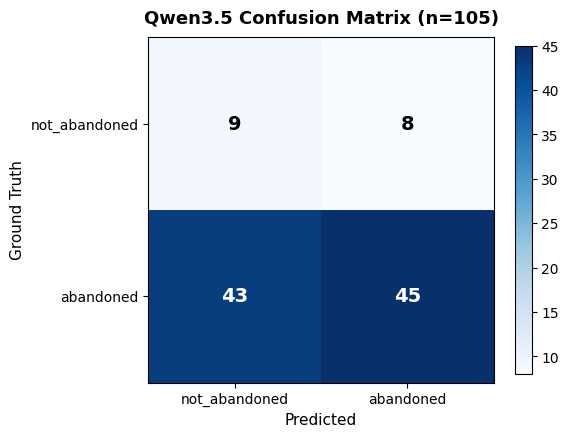

Saved to /Volumes/D/Leo/Study/CS Capstone/UrbanVision/output/evaluation/new-prompt/confusion_matrix.png


{'confusion_matrix': [[9, 8], [43, 45]],
 'labels': ['not_abandoned', 'abandoned'],
 'accuracy': 0.5143,
 'precision[abandoned]': 0.8491,
 'recall[abandoned]': 0.5114,
 'f1[abandoned]': 0.6383,
 'macro_f1': 0.4496}

In [5]:
labels = EVAL_CONFIG["label_order"]
y_true = merged["gt_label"].tolist()
y_pred = merged["final_decision"].tolist()

cm = confusion_matrix(y_true, y_pred, labels=labels)
report_dict = classification_report(
    y_true, y_pred, labels=labels, output_dict=True, zero_division=0
)

print("Confusion matrix (rows=ground truth, cols=predicted):")
cm_df = pd.DataFrame(cm, index=[f"GT={l}" for l in labels], columns=[f"Pred={l}" for l in labels])
print(cm_df.to_string())
print()
print("Classification report:")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

# ── Heatmap plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Ground Truth", fontsize=11)
ax.set_title(f"Qwen3.5 Confusion Matrix (n={n_total})", fontsize=13, fontweight="bold", pad=10)

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

cm_path = EVAL_CONFIG["output_dir"] / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {cm_path}")

positive = EVAL_CONFIG["positive_label"]
{
    "confusion_matrix": cm.tolist(),
    "labels": labels,
    "accuracy": round(report_dict["accuracy"], 4),
    f"precision[{positive}]": round(report_dict[positive]["precision"], 4),
    f"recall[{positive}]": round(report_dict[positive]["recall"], 4),
    f"f1[{positive}]": round(report_dict[positive]["f1-score"], 4),
    "macro_f1": round(report_dict["macro avg"]["f1-score"], 4),
}

### Breakdown by Confidence

In [6]:
conf_stats = (
    merged.groupby("confidence")["correct"]
    .agg(n_correct="sum", n_total="count", accuracy="mean")
    .round(4)
)
print(conf_stats.to_string())

conf_stats.reset_index().to_dict("records")

            n_correct  n_total  accuracy
confidence                              
high               34       68    0.5000
medium             20       37    0.5405


[{'confidence': 'high', 'n_correct': 34, 'n_total': 68, 'accuracy': 0.5},
 {'confidence': 'medium', 'n_correct': 20, 'n_total': 37, 'accuracy': 0.5405}]

### Export Mismatches

In [7]:
mismatches = merged.loc[
    ~merged["correct"],
    ["filename", "_id", "final_decision", "gt_label", "latest_inspection_score",
     "latest_inspection_result", "confidence", "reasoning"],
].reset_index(drop=True)

mismatch_path = EVAL_CONFIG["output_dir"] / "mismatches.csv"
mismatches.to_csv(mismatch_path, index=False)

print(f"Mismatches: {len(mismatches)} / {n_total}")
print(f"Exported to: {mismatch_path}")

{
    "n_mismatches": len(mismatches),
    "path": str(mismatch_path),
    "head": mismatches.head(5).to_dict("records"),
}

Mismatches: 51 / 105
Exported to: /Volumes/D/Leo/Study/CS Capstone/UrbanVision/output/evaluation/new-prompt/mismatches.csv


{'n_mismatches': 51,
 'path': '/Volumes/D/Leo/Study/CS Capstone/UrbanVision/output/evaluation/new-prompt/mismatches.csv',
 'head': [{'filename': '007_21588_front.jpg',
   '_id': 21588,
   'final_decision': 'not_abandoned',
   'gt_label': 'abandoned',
   'latest_inspection_score': 3.0,
   'latest_inspection_result': 'Fail',
   'confidence': 'medium',
   'reasoning': 'The image shows a red brick rowhouse in the center. While the lower portion of the wall shows significant white staining (likely efflorescence or peeling paint), the windows appear intact. The ground-floor windows are dark but appear to have white blinds or curtains drawn rather than being boarded up or broken. The front door is painted red and appears intact. There is no severe structural damage or overgrowth on the building itself. Although the neighbor to the left appears abandoned (with boarded windows and commercial-style painting), the central unit lacks definitive signs of abandonment like plywood, broken glass, or c

### Summary

After running all cells, the key metrics come from:

- **Suitable-only accuracy** — from the "Overall Accuracy" cell
- **Abandoned-class F1 / Precision / Recall** — from the "Confusion Matrix" cell
- **High vs Low confidence accuracy** — from the "Breakdown by Confidence" cell
- **Mismatch details** — [output/mismatches.csv](../output/mismatches.csv)
- **Confusion matrix plot** — [output/confusion_matrix.png](../output/confusion_matrix.png)

> The 34 `suitable=false` records are excluded from these metrics. For overall model coverage, report the `suitable=true` ratio separately: `103 / 137`.